# PC-TopoRidgeFormer v2.0 - cleaned, run-top-to-bottom local Jupyter notebook

Runs in a **local Jupyter** on your laptop (no Colab, no Google Drive, no uploads).
Edit **one line** in cell 1 (`BASE_DIR`) and run the cells in order. The notebook
finds your image zip/folder and the code bundle inside that folder by itself.

**Important:** ridge-count labels must come from real human examiners. SOCOFing
ships no ridge counts. Cell 5 therefore *stops* until a real expert CSV exists
(and writes a blank template you can hand to examiners). The old notebook filled
this CSV with `10 + idx % 15` and marked it expert-verified; that is removed.

> **Label provenance switch.** With `LABEL_SOURCE = "algorithmic"` (cell 1) the ridge counts come from a classical Gabor-based counter (cell 5B), not from examiners. They are written to `algorithmic_pair_counts.csv`, flagged `expert_verified = False`, and `CONFIRM_EXAMINER_LABELS` stays `False`. Anything this notebook reports in that mode measures agreement with that algorithm and must be described that way.

## 1. Setup: paths and switches (edit `BASE_DIR` only)

In [1]:
import importlib, json, re, shutil, subprocess, sys, zipfile
from pathlib import Path

# ---- EDIT THIS ONE LINE ------------------------------------------------------
# Folder on your laptop that contains (directly or nested) the SOCOFing images
# (zip OR folder) and the PC_TopoRidgeFormer_Code_Bundle_v2_0 (folder OR zip).
BASE_DIR = Path(r"C:\ZGeo\IDP")

# Optional: set these only if auto-detection in cells 2/3 picks the wrong thing.
IMAGES_SRC_OVERRIDE = None    # e.g. Path(r"D:\data\sokoto compressed (1).zip")  or a folder of .BMP files
BUNDLE_SRC_OVERRIDE = None    # e.g. Path(r"D:\code\PC_TopoRidgeFormer_Code_Bundle_v2_0")

# ---- Derived locations (all local) -------------------------------------------
WORK         = BASE_DIR / "work"
PROJECT      = BASE_DIR / "PC_TopoRidgeFormer"          # your outputs live here
MANIFEST_DIR = PROJECT / "data" / "manifests"
EXPERT_CSV   = PROJECT / "data" / "socofing_original" / "expert_pair_counts.csv"
ALGO_CSV     = PROJECT / "data" / "socofing_original" / "algorithmic_pair_counts.csv"
CONFIG_PATH  = PROJECT / "configs" / "resolved_publication_v2.json"
OUTPUT_DIR   = PROJECT / "outputs" / "publication_v2_full"
CACHE        = WORK / "cache" / "real_pair_strips"

# ---- Switches -----------------------------------------------------------------
# Where do the ridge-count labels come from?
#   "expert"      = real human examiners filled expert_pair_counts.csv (cells 5 and 6 as before)
#   "algorithmic" = generated by the classical ridge counter in cell 5B. These are NOT expert
#                   labels, are never marked expert_verified, and any result must be reported as
#                   "agreement with an algorithmic ridge counter", not as examiner-level accuracy.
LABEL_SOURCE = "algorithmic"
REGENERATE_ALGO_LABELS = False   # True = overwrite an existing algorithmic_pair_counts.csv
FAST_DEBUG   = False    # tiny search/training to prove the pipeline runs. False = full protocol.
FRESH_START  = True    # delete old Optuna study DBs / logs before the benchmark
INSTALL_DEPS = False    # pip-install requirements.txt (set False if your env is already set up)

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"BASE_DIR does not exist: {BASE_DIR}\n"
        "Edit the BASE_DIR line above to the folder that holds your data and code bundle.")
for d in (WORK, PROJECT):
    d.mkdir(parents=True, exist_ok=True)

import torch
print("Python:", sys.version.split()[0], "| torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("NOTE: no GPU detected. FAST_DEBUG runs are fine on CPU; the full protocol is not.")

Python: 3.13.7 | torch: 2.11.0+cu128
CUDA available: True


## 2. Locate the SOCOFing images (reads straight from your laptop)

In [2]:
def bmps_in(folder: Path):
    return [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() == ".bmp"]

def find_images_source():
    if IMAGES_SRC_OVERRIDE:
        return Path(IMAGES_SRC_OVERRIDE)
    zips = sorted(BASE_DIR.rglob("*.zip"))
    zips = [z for z in zips if "sokoto" in z.name.lower() or "socofing" in z.name.lower()]
    if zips:
        return zips[0]
    for d in BASE_DIR.rglob("*"):
        if d.is_dir() and WORK not in d.parents and d != WORK and \
           any(p.suffix.lower() == ".bmp" for p in d.glob("*")):
            return d
    raise FileNotFoundError(
        f"No SOCOFing zip or folder of .BMP files found under {BASE_DIR}.\n"
        "Set IMAGES_SRC_OVERRIDE in cell 1.")

IMAGES_SRC = find_images_source()
print("Images source:", IMAGES_SRC)

if IMAGES_SRC.is_dir():
    found = bmps_in(IMAGES_SRC)
    if not found:
        raise RuntimeError(f"No .BMP files inside {IMAGES_SRC}")
    IMG_DIR = found[0].parent                  # used in place, nothing is moved or copied
else:
    IMG_DIR = WORK / "socofing_original" / "Real"
    if not (IMG_DIR.exists() and bmps_in(IMG_DIR)):
        extract_to = WORK / "socofing_original"
        extract_to.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(IMAGES_SRC) as zf:
            zf.extractall(extract_to)
        found = bmps_in(extract_to)
        if not found:
            raise RuntimeError("Zip extracted but contained no .BMP files.")
        IMG_DIR.mkdir(parents=True, exist_ok=True)
        for p in found:                         # flatten e.g. 'to be used(sokoto)/' into Real/
            if p.parent != IMG_DIR:
                shutil.move(str(p), str(IMG_DIR / p.name))

def bmps(folder: Path):
    return [p for p in folder.glob("*") if p.suffix.lower() == ".bmp"]

n_img = len(bmps(IMG_DIR))
print(f"{n_img} BMP images in {IMG_DIR}")
assert n_img > 0
if n_img != 6000:
    print("NOTE: SOCOFing 'Real' normally has 6000 images; you have", n_img)

Images source: C:\ZGeo\IDP\sokoto compressed.zip
6000 BMP images in C:\ZGeo\IDP\work\socofing_original\Real


## 3. Locate the code bundle, install, and run the test-suite

In [3]:
def find_bundle_source():
    if BUNDLE_SRC_OVERRIDE:
        return Path(BUNDLE_SRC_OVERRIDE)
    for p in sorted(BASE_DIR.rglob("PC_TopoRidgeFormer_Code_Bundle*")):
        if WORK not in p.parents:
            return p
    # maybe the package folder itself is somewhere under BASE_DIR
    for p in BASE_DIR.rglob("pctoporidgeformer"):
        if (p / "__init__.py").exists() and WORK not in p.parents:
            return p.parent.parent
    raise FileNotFoundError(
        f"Code bundle not found under {BASE_DIR}. Set BUNDLE_SRC_OVERRIDE in cell 1.")

BUNDLE_SRC = find_bundle_source()
if BUNDLE_SRC.is_file() and BUNDLE_SRC.suffix.lower() == ".zip":
    target = WORK / "code_bundle"
    if not target.exists():
        with zipfile.ZipFile(BUNDLE_SRC) as zf:
            zf.extractall(target)
    BUNDLE_SRC = target

pkg = [p for p in BUNDLE_SRC.rglob("pctoporidgeformer")
       if (p / "__init__.py").exists() and ".venv" not in p.parts]
if not pkg:
    raise FileNotFoundError(f"No 'pctoporidgeformer' package found inside {BUNDLE_SRC}")
SOURCE = pkg[0].parent                          # folder holding pyproject.toml / requirements.txt
print("Code bundle:", BUNDLE_SRC)
print("Package root:", SOURCE)

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

if INSTALL_DEPS:
    if (SOURCE / "requirements.txt").exists():
        pip("-r", str(SOURCE / "requirements.txt"))
    pip("pytest")
pip("-e", str(SOURCE))

if str(SOURCE) not in sys.path:
    sys.path.insert(0, str(SOURCE))
importlib.invalidate_caches()
import pctoporidgeformer
print("Package imported from:", pctoporidgeformer.__file__)

subprocess.run([sys.executable, "-m", "pytest", "-q", str(SOURCE / "tests")],
               check=True, cwd=str(SOURCE))
subprocess.run([sys.executable, "-m", "compileall", "-q", str(SOURCE / "pctoporidgeformer")],
               check=True)
print("Tests and compile check passed.")
# If pip changed numpy/torch and the import above fails: Kernel > Restart, re-run from cell 1.

Code bundle: C:\ZGeo\IDP\PC_TopoRidgeFormer_Code_Bundle_v2_0
Package root: C:\ZGeo\IDP\PC_TopoRidgeFormer_Code_Bundle_v2_0\PC_TopoRidgeFormer
Package imported from: C:\ZGeo\IDP\PC_TopoRidgeFormer_Code_Bundle_v2_0\PC_TopoRidgeFormer\pctoporidgeformer\__init__.py
Tests and compile check passed.


In [4]:
import torch
print(torch.__version__, "| available:", torch.cuda.is_available())

2.11.0+cu128 | available: True


## 4. Manifest templates (copied once into your project folder)

In [4]:
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
for template in (SOURCE / "data" / "manifests").glob("*.json"):
    target = MANIFEST_DIR / template.name
    if not target.exists():
        shutil.copy2(template, target)
        print("Created template:", target.name)

for p in sorted(MANIFEST_DIR.glob("*.json")):
    print(f"{p.name:40s} sealed={json.loads(p.read_text()).get('sealed')}")

casia_v5.json                            sealed=False
nist_sd300.json                          sealed=False
nist_sd302.json                          sealed=False
polyu_contact_contactless.json           sealed=False
socofing_original.json                   sealed=False


## 5. Expert annotations (real examiner counts required)

The model is trained to predict the ridge count between two marked points.
Those counts must be produced by human examiners (two examiners per pair under
the default protocol). This cell:

* if `expert_pair_counts.csv` exists, validates it;
* if not, writes `expert_pair_counts_TEMPLATE.csv` (image/subject/finger columns
  pre-filled from filenames, everything an examiner must supply left blank) and stops.

*(Runs only when `LABEL_SOURCE = "expert"`. For algorithmic labels use cell 5B below.)*

In [5]:
if LABEL_SOURCE != "expert":
    print("LABEL_SOURCE is 'algorithmic' -> skipping the expert-CSV check; run cell 5B instead.")
else:
    import numpy as np
    import pandas as pd
    from pctoporidgeformer import data

    KNOWN_COLS = [
        "annotation_id", "image_relpath", "subject_id", "finger_id", "impression_id",
        "sensor_id", "x1", "y1", "x2", "y2", "ridge_count", "annotator_1_count",
        "annotator_2_count", "annotator_1_id", "annotator_2_id", "annotator_count",
        "adjudicated", "adjudicated_count", "adjudicator_id", "initial_agreement",
        "expert_verified", "count_is_censored", "quality", "ppi", "split",
    ]
    COLS = list(dict.fromkeys(KNOWN_COLS + list(data.REQUIRED_ANNOTATION_COLUMNS)))
    MUST_BE_FILLED = ["x1", "y1", "x2", "y2", "ridge_count", "annotator_1_count",
                      "annotator_2_count", "annotator_1_id", "annotator_2_id"]

    if not EXPERT_CSV.exists():
        pat = re.compile(r"(\d+)__([MF])_(Left|Right)_([A-Za-z]+)_finger", re.IGNORECASE)
        rows = []
        for i, img in enumerate(sorted(bmps(IMG_DIR)), start=1):
            m = pat.match(img.name)
            rows.append({
                "annotation_id": i, "image_relpath": img.name,
                "subject_id": int(m.group(1)) if m else "",
                "finger_id": f"{m.group(3)}_{m.group(4)}" if m else "",
                "impression_id": "real", "sensor_id": "optical_socofing",
            })
        template = pd.DataFrame(rows).reindex(columns=COLS)
        EXPERT_CSV.parent.mkdir(parents=True, exist_ok=True)
        tpl_path = EXPERT_CSV.with_name("expert_pair_counts_TEMPLATE.csv")
        template.to_csv(tpl_path, index=False)
        raise RuntimeError(
            "No expert annotation file yet.\n"
            f"A blank template with {len(template)} rows was written to:\n  {tpl_path}\n"
            "Have examiners fill the coordinates and counts (see ANNOTATION_PROTOCOL.md in the "
            "bundle), save the result as:\n  " + str(EXPERT_CSV) + "\nthen re-run this cell."
        )

    df = pd.read_csv(EXPERT_CSV)
    missing_cols = [c for c in data.REQUIRED_ANNOTATION_COLUMNS if c not in df.columns]
    problems = []
    if missing_cols:
        problems.append(f"missing columns: {missing_cols}")
    for c in MUST_BE_FILLED:
        if c in df.columns and df[c].isna().any():
            problems.append(f"{int(df[c].isna().sum())} blank values in '{c}'")
    if "image_relpath" in df.columns:
        absent = [p for p in df["image_relpath"] if not (IMG_DIR / p).exists()]
        if absent:
            problems.append(f"{len(absent)} image_relpath entries not found in {IMG_DIR} (e.g. {absent[:3]})")
    if problems:
        raise RuntimeError("Annotation CSV is not ready:\n- " + "\n- ".join(problems))

    print(f"Annotation CSV OK: {len(df)} rows, {df['subject_id'].nunique()} subjects")

LABEL_SOURCE is 'algorithmic' -> skipping the expert-CSV check; run cell 5B instead.


## 5B. Algorithmic ridge-count labels (only when `LABEL_SOURCE = "algorithmic"`)

Generates one ridge-count pair per image with a **classical ridge counter** (orientation field -> Gabor enhancement ->
crest counting along the segment between two points). Two differently tuned variants count each pair independently of
the pair sampler; by default only pairs on which both variants agree are kept.

What this is and is not:

* Labels are **algorithm-generated**. The CSV records `expert_verified = False` and annotator ids starting with `ALGO:`.
* The two variants share the same orientation field and the same filter family, so their agreement is **not** independent
  confirmation. Agreement filtering also biases the data toward easy pairs; say so in any write-up.
* Counting convention: crests strictly between the endpoints (a crest within 1.5 px of an endpoint is not counted).
  Compare this with `ANNOTATION_PROTOCOL.md` in the bundle and tell me if the protocol counts differently.
* Coordinates are written in **pixels** of the original BMP. Check the unit convention the bundle expects (the cell prints the relevant lines of `data.py`).
* Review the QA image this cell saves and count a few pairs by eye before trusting the file.

Lines in pctoporidgeformer/data.py mentioning coordinates / distance / count (first 25):
  "x1",
  "ridge_count",
  x1: int
  max_pair_distance: float = 384.0,
  x1, y1, x2, y2 = (
  _parse_int_exact(row[name], name) for name in ("x1", "y1", "x2", "y2")
  ridge_count = _parse_int_exact(row["ridge_count"], "ridge_count")
  if annotation_id < 0 or ridge_count < 0:
  if ridge_count != annotator_1_count or adjudicated or adjudicated_count is not None:
  or ridge_count != adjudicated_count
  endpoints = tuple(sorted(((x1, y1), (x2, y2))))
  distance = math.hypot(x2 - x1, y2 - y1)
  if distance <= 0 or distance > max_pair_distance:
  x1=x1,
  raw_label=ridge_count,
  max_pair_distance: float = 384.0,
  max_pair_distance=max_pair_distance,
  0 <= annotation.x1 < width
  cx = annotation.x1 + longitudinal * (annotation.x2 - annotation.x1)
  ny = (annotation.x2 - annotation.x1) / annotation.distance
  max_pair_distance: float = 384.0,
  max_pair_distance=max_pair_distance,
  max_pair_distance=ma

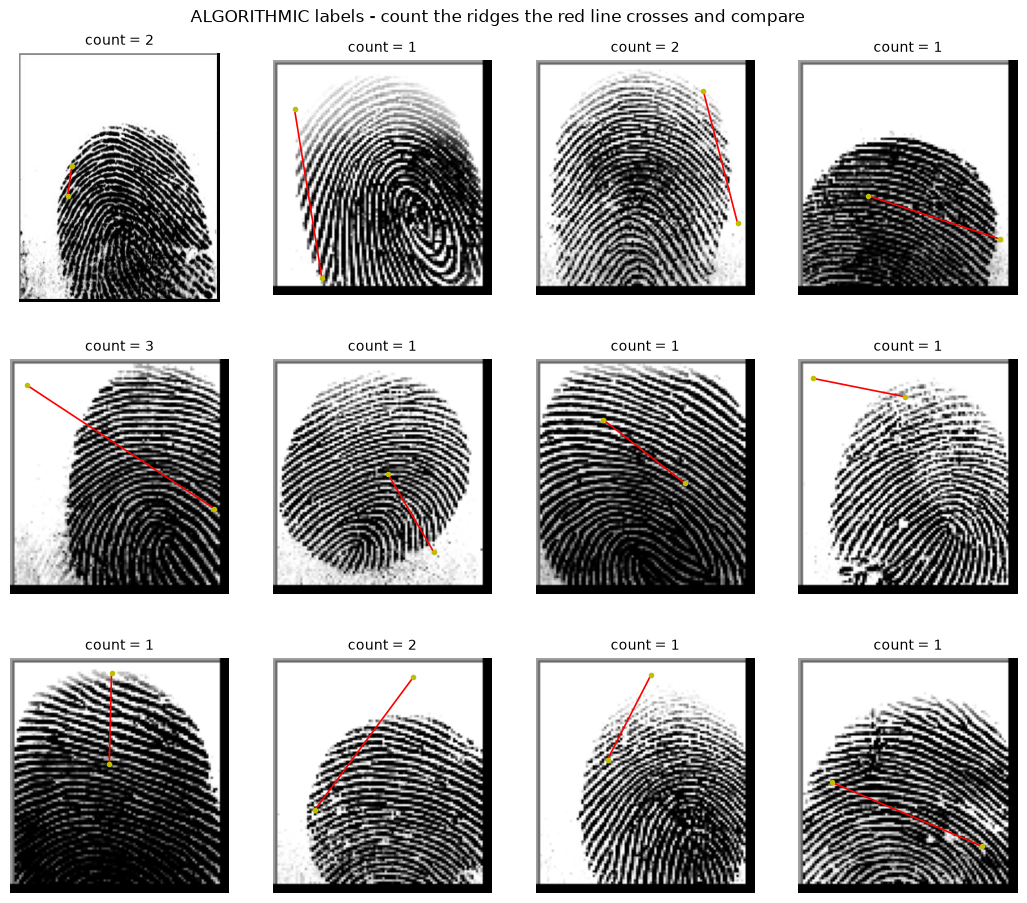

In [14]:
# ---- 5B: algorithmic labels --------------------------------------------------------------
if LABEL_SOURCE != "algorithmic":
    print("LABEL_SOURCE is 'expert' -> skipping algorithmic label generation.")
else:
    import sys, importlib
    from scipy import ndimage as ndi
    import numpy as np, pandas as pd

    RC_SOURCE = r'''import numpy as np
from scipy import ndimage as ndi
from scipy.signal import find_peaks, fftconvolve

ALGO_VERSION = "classical_gabor_v1"
ID_A = "ALGO:gabor_peak_counter_v1"
ID_B = "ALGO:gabor_hysteresis_counter_v1"


def prepare(gray):
    """gray: float image in [0,1], dark ridges on light background.
    Returns dict with ridge-positive normalised image, mask, orientation, coherence, period."""
    inv = 1.0 - gray.astype(np.float32)
    mu = ndi.gaussian_filter(inv, 6.0)
    sd = np.sqrt(ndi.gaussian_filter((inv - mu) ** 2, 6.0))
    imn = (inv - mu) / (sd + 0.03)

    gx = ndi.gaussian_filter(imn, 1.0, order=(0, 1))
    gy = ndi.gaussian_filter(imn, 1.0, order=(1, 0))
    gxx = ndi.gaussian_filter(gx * gx, 5.0)
    gyy = ndi.gaussian_filter(gy * gy, 5.0)
    gxy = ndi.gaussian_filter(gx * gy, 5.0)
    theta = np.mod(0.5 * np.arctan2(2 * gxy, gxx - gyy) + np.pi / 2, np.pi)  # ridge direction
    coh = np.sqrt((gxx - gyy) ** 2 + 4 * gxy ** 2) / (gxx + gyy + 1e-9)

    # foreground: enough local contrast AND coherent orientation
    thr = max(0.02, 0.4 * np.percentile(sd, 90))
    mask = (sd > thr) & (coh > 0.2)
    mask = ndi.binary_closing(mask, iterations=2)
    mask = ndi.binary_fill_holes(mask)
    mask = ndi.binary_opening(mask, iterations=2)
    lab, n = ndi.label(mask)
    if n > 1:
        sizes = ndi.sum(mask, lab, range(1, n + 1))
        mask = lab == (1 + int(np.argmax(sizes)))
    period = _estimate_period(imn, mask)
    return dict(imn=imn, mask=mask, theta=theta, coh=coh, period=period)


def _estimate_period(imn, mask, lo=5.0, hi=16.0):
    if mask.sum() < 200:
        return 9.0
    w = imn * mask
    w = w - w[mask].mean() * mask
    N = 256
    F = np.abs(np.fft.fftshift(np.fft.fft2(w, s=(N, N)))) ** 2
    f = np.fft.fftshift(np.fft.fftfreq(N))
    R = np.hypot(*np.meshgrid(f, f))
    edges = np.linspace(1 / hi, 1 / lo, 50)
    idx = np.digitize(R.ravel(), edges)
    num = np.bincount(idx, weights=F.ravel(), minlength=len(edges) + 1)
    den = np.bincount(idx, minlength=len(edges) + 1)
    prof = num[1:len(edges)] / np.maximum(den[1:len(edges)], 1)
    k = int(np.argmax(prof))
    return float(1.0 / (0.5 * (edges[k] + edges[k + 1])))


def _gabor(theta, period, su, sv):
    half = int(np.ceil(2.5 * max(su, sv)))
    y, x = np.mgrid[-half:half + 1, -half:half + 1].astype(np.float32)
    u = x * np.cos(theta) + y * np.sin(theta)       # along ridge
    v = -x * np.sin(theta) + y * np.cos(theta)      # across ridge
    g = np.exp(-0.5 * (u ** 2 / su ** 2 + v ** 2 / sv ** 2)) * np.cos(2 * np.pi * v / period)
    g -= g.mean()
    return g / np.abs(g).sum()


def enhance(prep, su_f, sv_f, period_scale=1.0, n_orient=16):
    p = prep["period"] * period_scale
    su, sv = su_f * p, sv_f * p
    pad = int(np.ceil(2.5 * max(su, sv)))
    im = np.pad(prep["imn"], pad, mode="reflect")
    stack = []
    for k in range(n_orient):
        g = _gabor(k * np.pi / n_orient, p, su, sv)
        r = fftconvolve(im, g, mode="same")[pad:-pad, pad:-pad]
        stack.append(r)
    stack = np.stack(stack)
    idx = np.rint(prep["theta"] / (np.pi / n_orient)).astype(int) % n_orient
    return np.take_along_axis(stack, idx[None], axis=0)[0]


def make_enhanced(prep):
    """Two differently-tuned enhancements (different bandwidth and period assumption)."""
    return dict(
        A=enhance(prep, su_f=0.55, sv_f=0.40, period_scale=1.00),
        B=enhance(prep, su_f=0.45, sv_f=0.33, period_scale=1.07),
    )


def profile(enh, p1, p2, step=0.5):
    (x1, y1), (x2, y2) = p1, p2
    L = float(np.hypot(x2 - x1, y2 - y1))
    n = max(int(np.ceil(L / step)) + 1, 5)
    xs, ys = np.linspace(x1, x2, n), np.linspace(y1, y2, n)
    vals = ndi.map_coordinates(enh, [ys, xs], order=1, mode="nearest")
    return xs, ys, vals, L / (n - 1)


def count_A(vals, ds, period, scale, margin_px=1.5):
    """Variant A: prominent crests of the smoothed enhanced profile."""
    s = ndi.gaussian_filter1d(vals, 0.5 / ds)
    pk, _ = find_peaks(s, prominence=0.30 * scale, distance=max(1, int(0.55 * period / ds)))
    m = margin_px / ds
    return int(np.sum((pk > m) & (pk < len(s) - 1 - m)))


def count_B(vals, ds, period, scale, margin_px=1.5):
    """Variant B: positive runs of the profile that reach a hysteresis height."""
    s = ndi.gaussian_filter1d(vals, 0.7 / ds)
    lab, n = ndi.label(s > 0)
    m = margin_px / ds
    c = 0
    for i in range(1, n + 1):
        ii = np.flatnonzero(lab == i)
        j = ii[np.argmax(s[ii])]
        if s[j] > 0.35 * scale and m < j < len(s) - 1 - m and len(ii) * ds >= 0.25 * period:
            c += 1
    return c
'''
    rc_path = PROJECT / "ridge_counter.py"
    rc_path.write_text(RC_SOURCE, encoding="utf-8")          # kept in your project for reproducibility
    if str(PROJECT) not in sys.path:
        sys.path.insert(0, str(PROJECT))
    import ridge_counter as rc
    importlib.reload(rc)
    from pctoporidgeformer import data
    from pctoporidgeformer.config import load_config

    # Show how the bundle itself describes the pair coordinates, so the unit convention can be verified.
    try:
        _src = inspect.getsource(data) if "inspect" in globals() else __import__("inspect").getsource(data)
    except Exception:
        _src = ""
    _hits = [l.strip() for l in _src.splitlines() if any(k in l for k in ("x1", "max_pair_distance", "ridge_count"))]
    print("Lines in pctoporidgeformer/data.py mentioning coordinates / distance / count (first 25):")
    print("\n".join("  " + l for l in _hits[:25]) or "  (could not read data.py source)")

    # =============================================================================
    # Pair sampling + CSV generation
    # =============================================================================
    import inspect, time
    import numpy as np, pandas as pd

    SEED = 1234
    REQUIRE_AGREEMENT = True     # keep only pairs where both algorithm variants give the same count
    MAX_TRIES = 60               # candidate pairs tried per image
    MIN_COUNT = 1
    MAX_IMAGES = None            # e.g. 200 for a quick trial; None = all images
    SELFTEST_FIRST = True

    try:
        _cfg = load_config(SOURCE / "configs" / "colab.json")
        DMAX = float(getattr(_cfg.data, "max_pair_distance", 60.0))
        MAX_COUNT = int(getattr(_cfg.model, "max_count", 30))
    except Exception as e:
        print("Could not read colab.json (", e, ") -> using DMAX=60, MAX_COUNT=30")
        DMAX, MAX_COUNT = 60.0, 30
    print(f"max_pair_distance={DMAX}  model.max_count={MAX_COUNT}  (distance assumed to be in PIXELS)")


    def sample_pair_for_image(gray, rng, dmin_f=2.5):
        prep = rc.prepare(gray)
        mk = ndi.binary_erosion(prep["mask"], iterations=3)
        ys, xs = np.nonzero(mk)
        H, W = gray.shape
        if len(xs) < 200:
            return None, dict(reason="small_foreground")
        enh = rc.make_enhanced(prep)
        scA = float(enh["A"][prep["mask"]].std()); scB = float(enh["B"][prep["mask"]].std())
        dmin = max(15.0, dmin_f * prep["period"]); dmax = min(DMAX, 0.9 * np.hypot(H, W))
        n_cand = n_agree = 0
        for _ in range(MAX_TRIES):
            i = rng.integers(len(xs)); d = rng.uniform(dmin, max(dmin + 1, dmax)); a = rng.uniform(0, 2 * np.pi)
            x1, y1 = int(xs[i]), int(ys[i])
            x2, y2 = int(round(x1 + d * np.cos(a))), int(round(y1 + d * np.sin(a)))
            if not (1 <= x2 <= W - 2 and 1 <= y2 <= H - 2):
                continue
            if not (dmin <= np.hypot(x2 - x1, y2 - y1) <= dmax):
                continue    # rounding must not push the pair outside the allowed distance
            X, Y, vA, dsA = rc.profile(enh["A"], (x1, y1), (x2, y2))
            if not mk[np.clip(np.rint(Y).astype(int), 0, H - 1), np.clip(np.rint(X).astype(int), 0, W - 1)].all():
                continue
            coh = float(ndi.map_coordinates(prep["coh"], [Y, X], order=1).mean())
            if coh < 0.30:
                continue
            _, _, vB, dsB = rc.profile(enh["B"], (x1, y1), (x2, y2))
            cA = rc.count_A(vA, dsA, prep["period"], scA)
            cB = rc.count_B(vB, dsB, prep["period"], scB)
            n_cand += 1; n_agree += int(cA == cB)
            if not (MIN_COUNT <= cA <= MAX_COUNT and MIN_COUNT <= cB <= MAX_COUNT):
                continue
            if REQUIRE_AGREEMENT and cA != cB:
                continue
            return dict(x1=x1, y1=y1, x2=x2, y2=y2,
                        cA=cA, cB=cB, quality=round(coh, 3)), dict(n_cand=n_cand, n_agree=n_agree)
        return None, dict(reason="no_valid_pair", n_cand=n_cand, n_agree=n_agree)


    def build_algorithmic_labels(template_df, img_dir, out_csv):
        from PIL import Image
        rows, dropped, n_cand_all, n_agree_all = [], [], 0, 0
        t0 = time.time(); n_total = len(template_df)
        for k, (_, r) in enumerate(template_df.iterrows(), start=1):
            gray = np.asarray(Image.open(Path(img_dir) / r["image_relpath"]).convert("L"), dtype=np.float32) / 255.0
            rng = np.random.default_rng(SEED + int(r["annotation_id"]))
            res, info = sample_pair_for_image(gray, rng)
            n_cand_all += info.get("n_cand", 0); n_agree_all += info.get("n_agree", 0)
            if res is None:
                dropped.append((r["image_relpath"], info.get("reason"))); continue
            row = r.to_dict()
            row.update(x1=res["x1"], y1=res["y1"], x2=res["x2"], y2=res["y2"],
                       ridge_count=res["cA"], annotator_1_count=res["cA"], annotator_2_count=res["cB"],
                       annotator_1_id=rc.ID_A, annotator_2_id=rc.ID_B, annotator_count=2,
                       adjudicated=False, initial_agreement=bool(res["cA"] == res["cB"]),
                       expert_verified=False, count_is_censored=False, quality=res["quality"],
                       label_source="ALGORITHMIC:" + rc.ALGO_VERSION)
            rows.append(row)
            if k % 250 == 0:
                el = time.time() - t0
                print(f"  {k}/{n_total} images  ({el:.0f}s, ~{el / k * (n_total - k):.0f}s left)")
        out = pd.DataFrame(rows)
        out.to_csv(out_csv, index=False)
        print(f"\nWrote {len(out)} algorithmic labels to {out_csv}")
        print(f"Images dropped (no valid pair): {len(dropped)}  e.g. {dropped[:3]}")
        if n_cand_all:
            print(f"Raw A-vs-B agreement over all candidate pairs: {n_agree_all / n_cand_all:.1%}")
        print("Ridge-count distribution:\n", out["ridge_count"].describe().round(2).to_string())
        return out


    # ---- sanity check on synthetic prints with KNOWN counts (runs in ~20 s) -------
    def _selftest():
        from scipy import ndimage as _nd
        H, W, period = 103, 96, 9.0
        rng = np.random.default_rng(5); ok = tot = 0
        for s in range(24):
            yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
            cx, cy = rng.uniform(30, 66), rng.uniform(35, 70); off = rng.uniform(0, 2 * np.pi)
            ph = lambda x, y: 2 * np.pi * np.hypot(x - cx, y - cy) / period + off
            img = _nd.gaussian_filter(0.5 + 0.4 * np.cos(ph(xx, yy)), 1.0) + rng.normal(0, 0.1, (H, W))
            foot = np.hypot((xx - W / 2) / (W * .46), (yy - H / 2) / (H * .46)) < 1
            img = np.clip(np.where(foot, img, 0.95), 0, 1).astype(np.float32)
            for _ in range(6):
                res, _i = sample_pair_for_image(img, rng)
                if res is None:
                    continue
                L = np.hypot(res["x2"] - res["x1"], res["y2"] - res["y1"]); n = int(L * 20) + 2
                p = ph(np.linspace(res["x1"], res["x2"], n), np.linspace(res["y1"], res["y2"], n))
                t_ = np.flatnonzero(np.diff(np.floor((p - np.pi) / (2 * np.pi))) != 0) / (n - 1) * L
                truth = int(np.sum((t_ > 1.5) & (t_ < L - 1.5)))
                tot += 1; ok += int(abs(res["cA"] - truth) <= 1)
        print(f"Self-test on synthetic prints: {ok}/{tot} labels within +/-1 of truth")
        assert tot > 20 and ok / tot > 0.9, "Counter failed its self-test - do not use these labels."


    if ALGO_CSV.exists() and not REGENERATE_ALGO_LABELS:
        print("Using existing", ALGO_CSV, "(set REGENERATE_ALGO_LABELS=True to rebuild)")
        algo_df = pd.read_csv(ALGO_CSV)
    else:
        if SELFTEST_FIRST:
            _selftest()
        # blank template (image / subject / finger columns from filenames), same layout as the expert template
        pat = re.compile(r"(\d+)__([MF])_(Left|Right)_([A-Za-z]+)_finger", re.IGNORECASE)
        _rows = []
        for i, img in enumerate(sorted(bmps(IMG_DIR)), start=1):
            m = pat.match(img.name)
            _rows.append({"annotation_id": i, "image_relpath": img.name,
                          "subject_id": int(m.group(1)) if m else "",
                          "finger_id": f"{m.group(3)}_{m.group(4)}" if m else "",
                          "impression_id": "real", "sensor_id": "optical_socofing"})
        _KNOWN = ["annotation_id", "image_relpath", "subject_id", "finger_id", "impression_id", "sensor_id",
                  "x1", "y1", "x2", "y2", "ridge_count", "annotator_1_count", "annotator_2_count",
                  "annotator_1_id", "annotator_2_id", "annotator_count", "adjudicated", "adjudicated_count",
                  "adjudicator_id", "initial_agreement", "expert_verified", "count_is_censored", "quality",
                  "ppi", "split", "label_source"]
        _COLS = list(dict.fromkeys(_KNOWN + list(data.REQUIRED_ANNOTATION_COLUMNS)))
        tpl = pd.DataFrame(_rows).reindex(columns=_COLS)
        if MAX_IMAGES:
            tpl = tpl.iloc[:MAX_IMAGES]
        ALGO_CSV.parent.mkdir(parents=True, exist_ok=True)
        algo_df = build_algorithmic_labels(tpl, IMG_DIR, ALGO_CSV)

    # ---- validation (same checks as cell 5, plus the provenance flags) ----
    _need = [c for c in data.REQUIRED_ANNOTATION_COLUMNS if c not in algo_df.columns]
    _fill = ["x1", "y1", "x2", "y2", "ridge_count", "annotator_1_count", "annotator_2_count",
             "annotator_1_id", "annotator_2_id"]
    _prob = ([f"missing columns: {_need}"] if _need else [])
    _prob += [f"{int(algo_df[c].isna().sum())} blank values in '{c}'" for c in _fill if algo_df[c].isna().any()]
    assert (algo_df["expert_verified"] == False).all(), "algorithmic labels must never be expert_verified"
    if _prob:
        raise RuntimeError("Algorithmic CSV not ready:\n- " + "\n- ".join(_prob))
    print(f"\nAlgorithmic CSV OK: {len(algo_df)} rows, {algo_df['subject_id'].nunique()} subjects, expert_verified=False")

    # ---- QA picture: 12 random pairs, eyeball the counts ----
    import matplotlib.pyplot as plt
    from PIL import Image
    qa = algo_df.sample(min(12, len(algo_df)), random_state=0)
    fig, axes = plt.subplots(3, 4, figsize=(13, 11))
    for ax, (_, r) in zip(axes.ravel(), qa.iterrows()):
        ax.imshow(Image.open(IMG_DIR / r["image_relpath"]).convert("L"), cmap="gray")
        ax.plot([r.x1, r.x2], [r.y1, r.y2], "r-", lw=1.2)
        ax.plot([r.x1, r.x2], [r.y1, r.y2], "yo", ms=3)
        ax.set_title(f"count = {int(r.ridge_count)}", fontsize=10); ax.axis("off")
    plt.suptitle("ALGORITHMIC labels - count the ridges the red line crosses and compare", y=0.92)
    (PROJECT / "qa").mkdir(exist_ok=True)
    plt.savefig(PROJECT / "qa" / "algorithmic_label_check.png", dpi=130, bbox_inches="tight")
    plt.show()


## 6. Confirm provenance and seal the manifest

Set the three flags to `True` **only if they are actually true**. Sealing hashes
the CSV and every image; it cannot make an unsupported provenance claim true.

In `algorithmic` mode only `CONFIRM_REAL_HUMAN_ACQUISITIONS` and `CONFIRM_LICENSE_ACCESS` are needed; `CONFIRM_EXAMINER_LABELS` must stay `False`. If sealing or preflight then refuses the data because it is not expert-verified, that check is the bundle doing its job; send me `pctoporidgeformer/data.py` and I will adapt the gate explicitly instead of bypassing it silently.

In [15]:
CONFIRM_REAL_HUMAN_ACQUISITIONS = True   # images are official real fingerprints, original-only
CONFIRM_EXAMINER_LABELS         = False   # counts came from human examiners, not a model/script
                                          # (leave False for LABEL_SOURCE="algorithmic": it would be untrue)
CONFIRM_LICENSE_ACCESS          = True   # dataset terms reviewed and accepted

if LABEL_SOURCE == "expert":
    _ok = CONFIRM_REAL_HUMAN_ACQUISITIONS and CONFIRM_EXAMINER_LABELS and CONFIRM_LICENSE_ACCESS
    ANNOT_CSV = EXPERT_CSV
else:
    _ok = CONFIRM_REAL_HUMAN_ACQUISITIONS and CONFIRM_LICENSE_ACCESS
    ANNOT_CSV = ALGO_CSV
    if CONFIRM_EXAMINER_LABELS:
        raise RuntimeError("CONFIRM_EXAMINER_LABELS must stay False: the labels are algorithmic.")
if not _ok:
    raise RuntimeError("Set the applicable CONFIRM_* flags above to True once each is genuinely verified.")

from pctoporidgeformer.data import seal_dataset_manifest

manifest_path = MANIFEST_DIR / "socofing_original.json"
cfg = json.loads(manifest_path.read_text())
print("Manifest keys:", sorted(cfg))

cfg["image_root"] = str(IMG_DIR)
cfg.pop("image_dir", None)
cfg["annotations_csv"] = str(ANNOT_CSV)           # stays on your laptop
cfg["license_or_access_confirmed"] = True
cfg["role"] = "development"
cfg["sealed"] = False                              # unlock, then seal once
manifest_path.write_text(json.dumps(cfg, indent=2))

seal_report = seal_dataset_manifest(manifest_path)
print("Sealed:", seal_report)

Manifest keys: ['access_terms_url', 'annotation_sha256', 'annotations_csv', 'dataset_id', 'display_name', 'expert_pair_counts', 'group_unit', 'image_inventory_sha256', 'image_kind', 'image_root', 'license_or_access_confirmed', 'pseudo_labels_used', 'role', 'schema_version', 'sealed', 'source_url', 'synthetic_content_present']
Sealed: {'dataset_id': 'socofing_original', 'annotation_sha256': '202022677b191d3090997ce2151815554891f0cfb70e0822251c1f81682475c8', 'image_inventory_sha256': '8155961d91d3036a37efa18a3283a9efc0c9ac76dade7fd3e5e504ee276c712a', 'images': 5497, 'status': 'SEALED'}


## 7. Resolve configuration (must run before preflight and model build)

In [6]:
from pctoporidgeformer.config import load_config, save_config

config = load_config(SOURCE / "configs" / "colab.json")
applied, skipped = [], []

def setv(section, name, value):
    obj = getattr(config, section, None)
    if obj is not None and hasattr(obj, name):
        setattr(obj, name, value); applied.append(f"{section}.{name}={value}")
    else:
        skipped.append(f"{section}.{name}")

setv("data", "development_manifest", str(MANIFEST_DIR / "socofing_original.json"))
setv("data", "external_manifests", [])     # SOCOFing is the only cohort here
if LABEL_SOURCE != "expert":
    # Labels are algorithmic and flagged expert_verified=False. Set explicitly so the
    # benchmark's preflight matches the notebook's own check. Results must be reported
    # as agreement with an algorithmic ridge counter.
    setv("data", "require_expert_verification", False)
setv("data", "cache_root", str(CACHE))
setv("runtime", "output_dir", str(OUTPUT_DIR))

SIX_HOUR_RUN = True    # False = full protocol from colab.json (days, not hours)
if (not FAST_DEBUG) and SIX_HOUR_RUN:
    setv("cv", "outer_folds", 5)
    setv("cv", "inner_folds", 2)
    setv("cv", "hpo_trials", 10)
    setv("cv", "baseline_hpo_trials", 5)
    setv("cv", "hpo_epochs", 10)
    setv("train", "seeds", [17, 42, 101])

config.validate()
CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
save_config(config, CONFIG_PATH)
print("Applied:", *applied, sep="\n  ")
if skipped:
    print("NOT applied (attribute not in this config version):", *skipped, sep="\n  ")
print("Saved:", CONFIG_PATH)

Applied:
  data.development_manifest=C:\ZGeo\IDP\PC_TopoRidgeFormer\data\manifests\socofing_original.json
  data.external_manifests=[]
  data.require_expert_verification=False
  data.cache_root=C:\ZGeo\IDP\work\cache\real_pair_strips
  runtime.output_dir=C:\ZGeo\IDP\PC_TopoRidgeFormer\outputs\publication_v2_full
  cv.outer_folds=5
  cv.inner_folds=2
  cv.hpo_trials=10
  cv.baseline_hpo_trials=5
  cv.hpo_epochs=10
  train.seeds=[17, 42, 101]
Saved: C:\ZGeo\IDP\PC_TopoRidgeFormer\configs\resolved_publication_v2.json


## 8. Preflight the data and build the model

In [6]:
from dataclasses import asdict
from pctoporidgeformer.baselines import build_model
from pctoporidgeformer.config import load_config
from pctoporidgeformer.data import preflight_real_data

config = load_config(CONFIG_PATH)

report = preflight_real_data(
    MANIFEST_DIR / "socofing_original.json",
    max_pair_distance=config.data.max_pair_distance,
    min_annotators=config.data.min_annotators,
    min_groups=config.data.min_development_groups,
    require_seal=True,
    require_real_only=True,
    require_expert_verification=(LABEL_SOURCE == "expert"),   # algorithmic labels are never expert-verified
    protocol=config.data.protocol,
    model_max_count=config.model.max_count,
)
print("Preflight passed:", report)

model = build_model(config.model, config.data.strip_height, config.data.max_width)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print({"architecture": config.model.architecture, "trainable_parameters": n_params})

Preflight passed: {'dataset_id': 'socofing_original', 'role': 'development', 'annotation_sha256': '202022677b191d3090997ce2151815554891f0cfb70e0822251c1f81682475c8', 'image_inventory_sha256': '8155961d91d3036a37efa18a3283a9efc0c9ac76dade7fd3e5e504ee276c712a', 'annotations_after_filtering': 5497, 'required_images': 5497, 'independent_groups': 600, 'group_unit': 'subject', 'maximum_exact_label': 15, 'censored_labels': 0, 'coordinate_bounds_checked': 5497, 'real_only_attestation': True, 'expert_verified_attestation': True, 'annotation_reliability': {'pairs': 5497, 'initial_exact_agreement': 1.0, 'initial_mae': 0.0, 'initial_rmse': 0.0, 'quadratic_weighted_kappa': 1.0, 'adjudication_rate': 0.0, 'by_sensor': [{'sensor_id': 'optical_socofing', 'pairs': 5497, 'initial_exact_agreement': 1.0, 'initial_mae': 0.0}]}, 'status': 'PASS_REAL_EXPERT_DATA_INTEGRITY'}
{'architecture': 'pc_toporidgeformer', 'trainable_parameters': 687908}


## 9. Benchmark suite

With `FAST_DEBUG=True` this is a short pipeline check, not a result. For the
full protocol set `FAST_DEBUG=False`, re-run cell 7, and expect many hours on a GPU (impractical on CPU).
If the kernel dies, re-run cells 1-3 and 7, then this cell: studies and
checkpoints resume from disk (set `FRESH_START=False` to keep them).

In [ ]:
from pctoporidgeformer.experiment import run_benchmark_suite

if FRESH_START and OUTPUT_DIR.exists():
    for pattern in ("*.db*", "*.log"):
        for f in OUTPUT_DIR.glob(pattern):
            f.unlink(); print("Removed", f.name)

print("Launching benchmark suite...")
benchmark_result = run_benchmark_suite(CONFIG_PATH)

print(json.dumps({k: benchmark_result.get(k) for k in (
    "claim_status", "claim_permitted", "all_models_converged",
    "internal_primary_baseline_superiority",
    "external_primary_baseline_noninferiority")}, indent=2))

Launching benchmark suite...


[I 2026-10-07 04:06:52,524] A new study created in RDB with name: pc_toporidgeformer_outer_0_0e926d1d3bb6
[I 2026-10-07 04:15:32,432] Trial 0 finished with value: 0.8903877054805369 and parameters: {'learning_rate': 0.00017432451659603007, 'weight_decay': 0.0032859708169642424, 'lambda_symmetry': 0.1205712628744377, 'lambda_js': 0.03830550353885683, 'width_heads': '192x6', 'dropout': 0.17022300234864177, 'n_layers': 4, 'ff_multiplier': 3, 'gabor_orientations': 8, 'gabor_frequencies': 9, 'lambda_physics': 0.07178258629674189, 'residual_max': 3.0296322368059485, 'lambda_residual': 0.0017258215396624998}. Best is trial 0 with value: 0.8903877054805369.
[I 2026-10-07 04:21:24,921] Trial 1 finished with value: 1.0050032869708576 and parameters: {'learning_rate': 0.00014262140993846114, 'weight_decay': 2.265486450485178e-05, 'lambda_symmetry': 0.04717052037625178, 'lambda_js': 0.07223873056359344, 'width_heads': '160x5', 'dropout': 0.17150897038028767, 'n_layers': 2, 'ff_multiplier': 4, 'gab

epoch=001 train_nll=1.28100 validation_nll=0.99457 lr=6.08e-04
epoch=002 train_nll=0.94854 validation_nll=0.93869 lr=6.08e-04
epoch=003 train_nll=0.89592 validation_nll=0.84343 lr=6.08e-04
epoch=004 train_nll=0.87260 validation_nll=0.94702 lr=6.08e-04
epoch=005 train_nll=0.85216 validation_nll=0.85945 lr=6.08e-04
epoch=006 train_nll=0.79752 validation_nll=0.81197 lr=6.08e-04
epoch=007 train_nll=0.78822 validation_nll=0.80424 lr=6.08e-04
epoch=008 train_nll=0.78282 validation_nll=0.82930 lr=6.08e-04
epoch=009 train_nll=0.74399 validation_nll=0.79709 lr=6.08e-04
epoch=010 train_nll=0.73307 validation_nll=0.86259 lr=6.08e-04
epoch=011 train_nll=0.71969 validation_nll=0.88233 lr=6.08e-04
epoch=012 train_nll=0.69651 validation_nll=0.85007 lr=6.08e-04
epoch=013 train_nll=0.68864 validation_nll=0.86561 lr=6.08e-04
epoch=014 train_nll=0.66364 validation_nll=1.10184 lr=6.08e-04
epoch=015 train_nll=0.67592 validation_nll=1.00157 lr=6.08e-04
epoch=016 train_nll=0.63404 validation_nll=0.93664 lr=3

C:\ZGeo\IDP\PC_TopoRidgeFormer_Code_Bundle_v2_0\PC_TopoRidgeFormer\pctoporidgeformer\calibration.py:23: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  label_tensor = torch.as_tensor(labels, dtype=torch.long)
[I 2026-10-07 05:51:27,442] A new study created in RDB with name: pc_toporidgeformer_outer_1_e53567a78d8c
[I 2026-10-07 05:56:17,684] Trial 0 finished with value: 0.9031622674326459 and parameters: {'learning_rate': 9.264560990653838e-05, 'weight_decay': 0.00017902713409413264, 'lambda_symmetry': 0.01574108370689597, 'lambda_js': 0.011333134570705533, 'width_heads': '128x4',

epoch=001 train_nll=1.26756 validation_nll=0.96941 lr=2.08e-04
epoch=002 train_nll=0.99922 validation_nll=0.92158 lr=2.08e-04
epoch=003 train_nll=0.94976 validation_nll=0.92472 lr=2.08e-04
epoch=004 train_nll=0.92697 validation_nll=0.94844 lr=2.08e-04
epoch=005 train_nll=0.87553 validation_nll=0.82530 lr=2.08e-04
epoch=006 train_nll=0.82957 validation_nll=0.80577 lr=2.08e-04
epoch=007 train_nll=0.80524 validation_nll=0.92118 lr=2.08e-04
epoch=008 train_nll=0.78836 validation_nll=0.83688 lr=2.08e-04
epoch=009 train_nll=0.76007 validation_nll=0.84304 lr=2.08e-04
epoch=010 train_nll=0.76327 validation_nll=0.79388 lr=2.08e-04
epoch=011 train_nll=0.74143 validation_nll=0.87733 lr=2.08e-04
epoch=012 train_nll=0.72117 validation_nll=0.90614 lr=2.08e-04
epoch=013 train_nll=0.72830 validation_nll=0.76542 lr=2.08e-04
epoch=014 train_nll=0.71120 validation_nll=0.77669 lr=2.08e-04
epoch=015 train_nll=0.70679 validation_nll=0.84021 lr=2.08e-04
epoch=016 train_nll=0.68249 validation_nll=0.87090 lr=2

[I 2026-10-07 07:35:43,857] A new study created in RDB with name: pc_toporidgeformer_outer_2_5d0150a9b8bb
[I 2026-10-07 07:41:09,031] Trial 0 finished with value: 0.9299988973317838 and parameters: {'learning_rate': 0.0005350006507781238, 'weight_decay': 2.4413927279895e-06, 'lambda_symmetry': 0.12587059426622965, 'lambda_js': 0.01704015151004142, 'width_heads': '128x4', 'dropout': 0.1519804819179213, 'n_layers': 4, 'ff_multiplier': 2, 'gabor_orientations': 16, 'gabor_frequencies': 7, 'lambda_physics': 0.05692640380480884, 'residual_max': 3.092080034517098, 'lambda_residual': 0.0017234762708589644}. Best is trial 0 with value: 0.9299988973317838.
[I 2026-10-07 07:45:24,416] Trial 1 finished with value: 0.9129047357085289 and parameters: {'learning_rate': 0.00021399481585260453, 'weight_decay': 0.0017076297397503788, 'lambda_symmetry': 0.024085875662623515, 'lambda_js': 0.047977287667837876, 'width_heads': '96x4', 'dropout': 0.08457898531645983, 'n_layers': 2, 'ff_multiplier': 4, 'gabor

epoch=001 train_nll=1.27168 validation_nll=1.03638 lr=5.33e-04
epoch=002 train_nll=1.04014 validation_nll=0.91204 lr=5.33e-04
epoch=003 train_nll=0.96702 validation_nll=0.87879 lr=5.33e-04
epoch=004 train_nll=0.91676 validation_nll=0.82466 lr=5.33e-04
epoch=005 train_nll=0.87786 validation_nll=0.82509 lr=5.33e-04
epoch=006 train_nll=0.85475 validation_nll=0.77738 lr=5.33e-04
epoch=007 train_nll=0.84262 validation_nll=0.79664 lr=5.33e-04
epoch=008 train_nll=0.82791 validation_nll=0.94025 lr=5.33e-04
epoch=009 train_nll=0.81202 validation_nll=0.92419 lr=5.33e-04
epoch=010 train_nll=0.79535 validation_nll=0.79371 lr=5.33e-04
epoch=011 train_nll=0.78600 validation_nll=0.80855 lr=5.33e-04
epoch=012 train_nll=0.80339 validation_nll=0.77721 lr=5.33e-04
epoch=013 train_nll=0.76992 validation_nll=0.76717 lr=5.33e-04
epoch=014 train_nll=0.75067 validation_nll=0.77077 lr=5.33e-04
epoch=015 train_nll=0.73953 validation_nll=0.78489 lr=5.33e-04
epoch=016 train_nll=0.71339 validation_nll=0.80036 lr=5

[I 2026-10-07 09:17:14,833] A new study created in RDB with name: pc_toporidgeformer_outer_3_25c428883490
[I 2026-10-07 09:21:21,537] Trial 0 finished with value: 0.9578360784456041 and parameters: {'learning_rate': 0.0007788687095422928, 'weight_decay': 0.00010783244701035444, 'lambda_symmetry': 0.026045445589024878, 'lambda_js': 0.006503334089316465, 'width_heads': '128x4', 'dropout': 0.0731901422995889, 'n_layers': 3, 'ff_multiplier': 4, 'gabor_orientations': 12, 'gabor_frequencies': 7, 'lambda_physics': 0.07145179997103006, 'residual_max': 2.774249210117853, 'lambda_residual': 0.0015526289819956887}. Best is trial 0 with value: 0.9578360784456041.
[I 2026-10-07 09:27:18,688] Trial 1 finished with value: 0.9499834594468086 and parameters: {'learning_rate': 0.00012167864910459792, 'weight_decay': 5.8904791141091526e-05, 'lambda_symmetry': 0.022834065007521512, 'lambda_js': 0.01870971739065825, 'width_heads': '160x5', 'dropout': 0.19127429692159925, 'n_layers': 2, 'ff_multiplier': 4, 

epoch=001 train_nll=1.20210 validation_nll=0.99651 lr=1.11e-04
epoch=002 train_nll=1.01650 validation_nll=1.27328 lr=1.11e-04
epoch=003 train_nll=0.94546 validation_nll=0.89885 lr=1.11e-04
epoch=004 train_nll=0.91502 validation_nll=0.86462 lr=1.11e-04
epoch=005 train_nll=0.88121 validation_nll=0.98016 lr=1.11e-04
epoch=006 train_nll=0.88268 validation_nll=0.91269 lr=1.11e-04
epoch=007 train_nll=0.85883 validation_nll=0.92093 lr=1.11e-04
epoch=008 train_nll=0.83571 validation_nll=0.91184 lr=1.11e-04
epoch=009 train_nll=0.81812 validation_nll=0.82606 lr=1.11e-04
epoch=010 train_nll=0.83506 validation_nll=0.79547 lr=1.11e-04
epoch=011 train_nll=0.79740 validation_nll=0.83116 lr=1.11e-04
epoch=012 train_nll=0.78664 validation_nll=0.83128 lr=1.11e-04
epoch=013 train_nll=0.77255 validation_nll=0.81224 lr=1.11e-04
epoch=014 train_nll=0.76370 validation_nll=0.76655 lr=1.11e-04
epoch=015 train_nll=0.76301 validation_nll=0.74290 lr=1.11e-04
epoch=016 train_nll=0.73109 validation_nll=0.75491 lr=1

## 10. Convergence audit

In [9]:
import pandas as pd

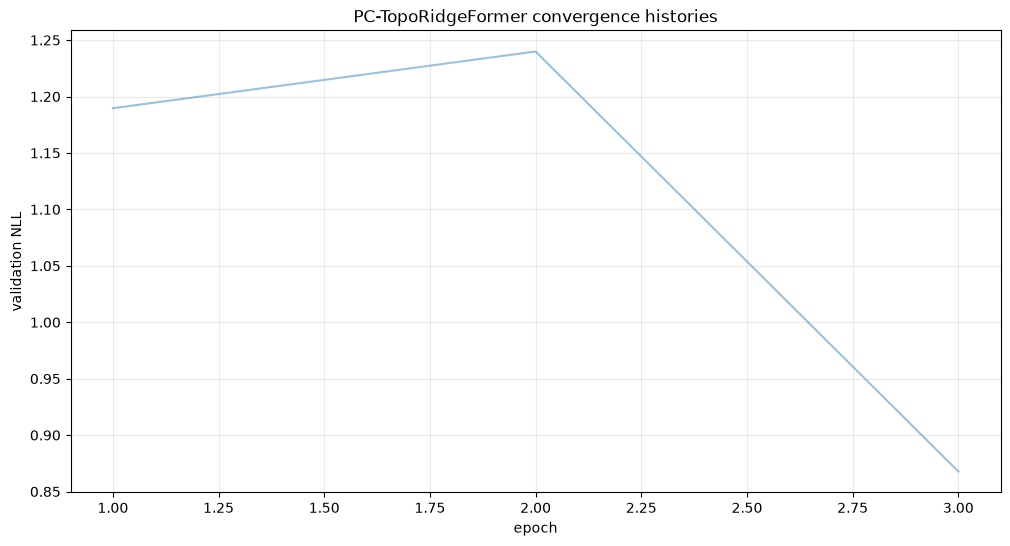

In [10]:
import matplotlib.pyplot as plt
from pctoporidgeformer.config import load_config

config = load_config(CONFIG_PATH)
output_root = Path(config.runtime.output_dir)

rows = []
for arch in ["pc_toporidgeformer", *config.benchmark.baselines]:
    for path in (output_root / arch).glob("outer_fold_*/models/*.history.json"):
        for r in json.loads(path.read_text())["history"]:
            rows.append({"architecture": arch,
                         "run": str(path.relative_to(output_root)), **r})
history = pd.DataFrame(rows)
if history.empty:
    raise RuntimeError("No training histories found under " + str(output_root))

fig, ax = plt.subplots(figsize=(12, 6))
for run, g in history[history.architecture == "pc_toporidgeformer"].groupby("run"):
    ax.plot(g.epoch, g.validation_nll, alpha=0.45)
ax.set(xlabel="epoch", ylabel="validation NLL",
       title="PC-TopoRidgeFormer convergence histories")
ax.grid(alpha=0.25)
plt.show()

## 11. Statistical results and claim decision

In [11]:
from IPython.display import display

output_root = Path(load_config(CONFIG_PATH).runtime.output_dir)
gate_path = output_root / "ROBUSTNESS_AND_SUPERIORITY_GATE.json"
if not gate_path.exists():
    print("Gate file not produced:", gate_path,
          "\n(A reduced FAST_DEBUG run may not reach the final gate.)")
else:
    gate = json.loads(gate_path.read_text())
    out = []
    for baseline, r in gate["internal_comparisons"].items():
        ea, ma = r["exact_accuracy_difference"], r["mae_difference"]
        out.append({"baseline": baseline,
                    "delta_exact": ea["estimate"], "exact_ci_low": ea["ci_95_lower"],
                    "exact_ci_high": ea["ci_95_upper"],
                    "delta_mae": ma["estimate"], "mae_ci_low": ma["ci_95_lower"],
                    "mae_ci_high": ma["ci_95_upper"],
                    "holm_p": r["holm_adjusted_p_value"],
                    "pass": r["internal_superiority_pass"]})
    display(pd.DataFrame(out))
    print("FINAL CLAIM DECISION:", gate["claim_status"])
    if not gate["claim_permitted"]:
        print("No robustness/superiority claim is statistically permitted.")

if LABEL_SOURCE != "expert":
    print("\nPROVENANCE: labels are ALGORITHMIC (" + str(ALGO_CSV.name) + "). Report results as agreement with a "
          "classical ridge counter, not as examiner-level accuracy.")

Gate file not produced: C:\ZGeo\IDP\PC_TopoRidgeFormer\outputs\publication_v2\ROBUSTNESS_AND_SUPERIORITY_GATE.json 
(A reduced FAST_DEBUG run may not reach the final gate.)

PROVENANCE: labels are ALGORITHMIC (algorithmic_pair_counts.csv). Report results as agreement with a classical ridge counter, not as examiner-level accuracy.


## 12. Freeze environment

**Interpretation rule:** report trained/converged only if every final seed passed;
report robust superiority only if the gate says `ROBUST_SUPERIORITY_ESTABLISHED`.
Otherwise report observed effects, intervals, and failed criteria.

In [12]:
(PROJECT / "outputs").mkdir(parents=True, exist_ok=True)
with (PROJECT / "outputs" / "environment_freeze.txt").open("w") as fh:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=fh, check=True)
print("Artifacts:", OUTPUT_DIR)

Artifacts: C:\ZGeo\IDP\PC_TopoRidgeFormer\outputs\publication_v2
